In [30]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
from mrvis.utils.matplotlib_style import gcolor

filepath = "/home/max/Temp"

all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))

Found 109 files


Processing /home/max/Temp/reconnection_rates_step_0070.txt


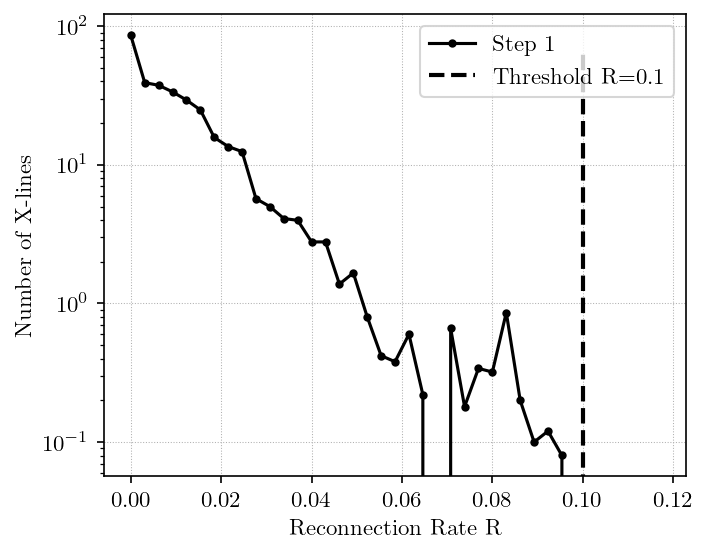

In [68]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    data2 = np.loadtxt(all_files[60])
    # data = np.copy(data[np.where(data > 0.0)])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=True)
    x2, bins2 = np.histogram(data2, bins=bins, density=True)
    plt.plot(bins[:-1], x2, ".-", linewidth=1.5, color=gradient[step], label=f"Step {step + 1}")
    # plt.hist(data, bins=bins, density=True, color="orange", label="$t=70/\Omega_{ci}$", rwidth=0.8)
    # plt.show()
    return np.max(x), data


bins=40  
max_reconnection_rate = 0.12

plt.figure(figsize=(5,4), dpi=150)

max_val = 0.0
all_data = np.array([])
for i, datapath in enumerate([all_files[66]]):
    print(f"Processing {datapath}")
    max_val_new, data = plot_histogram(i, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
    all_data = np.concatenate((all_data, data))
    if max_val_new > max_val:
        max_val = max_val_new



# bins = np.linspace(0.0, max_reconnection_rate, bins) 
# x, bins = np.histogram(all_data, bins=bins, density=False)
# plt.plot(bins[:-1], x, linewidth=1.5, color="black", label="Histogram")
# max_val = np.max(x)

plt.vlines(0.1, 0.0, max_val, color="black", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
# plt.hlines(10.0, 0.0, 0.2, color="gray", linestyle="--", linewidth=2.0, label="Noise Level")
plt.yscale("log")
# plt.xscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend()

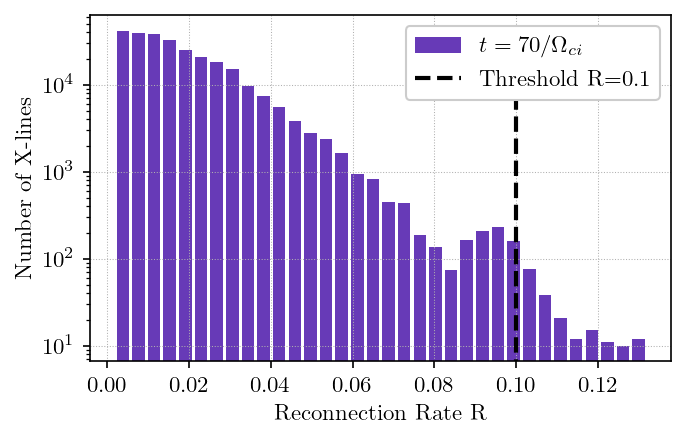

In [29]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    plt.hist(data, bins=bins, density=False, color=gcolor("violet"), label=r"$t=70/\Omega_{ci}$", rwidth=0.8, align="right")
    # plt.show()
    return np.max(x), data

datapath = "/home/max/Temp/reconnection_rates_step_0070.txt"
bins=35
max_reconnection_rate = 0.13

plt.figure(figsize=(5,3), dpi=150)

max_val_new, data = plot_histogram(1, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)

plt.vlines(0.1, 0.0, max_val_new, color="black", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
plt.yscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend(framealpha=1.0)
plt.savefig("reconnection_rate_histogram.png", bbox_inches="tight", dpi=300)

<Figure size 600x450 with 0 Axes>

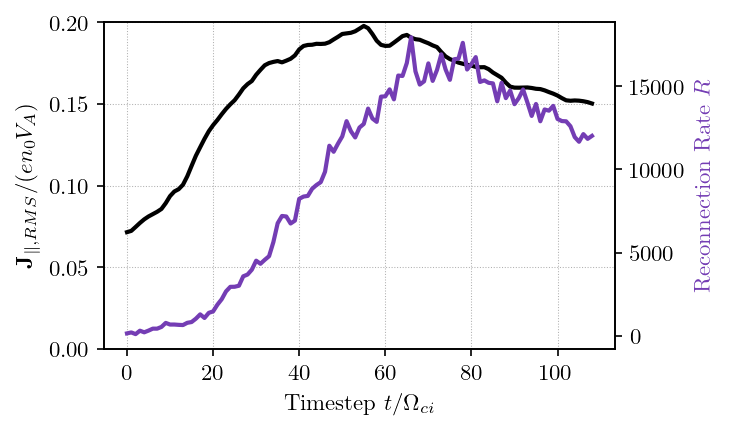

In [13]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")

def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 5.0)])
    max_r = np.mean(data)
    return max_r, len(data)

plt.figure(figsize=(4,3), dpi=150)

max_reconnection_rates = []
number_of_lines = []
for i, datapath in enumerate(all_files):
    max_r, n = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)
    number_of_lines.append(n)

fig, ax1 = plt.subplots(figsize=(5,3), dpi=150)

ax2 = ax1.twinx()
# ax2.plot(np.arange(1, number_of_files + 1), max_reconnection_rates,color=gcolor("violet"), linewidth=2.0)

# ax2.plot(number_of_points[:,0][:-5], number_of_points[:,1][:-5]/1e5, color="#743db4", linewidth=2)
ax1.plot(current_density[:,1], color="black", linewidth=2)
ax2.plot(number_of_lines, color="#743db4", linewidth=2.0)
ax1.set_ylim(0,0.2)
ax1.set_xlabel(r"Timestep $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")
ax2.set_ylabel("Reconnection Rate $R$", color="#743db4")
ax2.grid(False)
plt.tight_layout()
# plt.savefig("/home/max/Nextcloud/Bachelor/Media/Plots/num_points_lines.pdf", dpi=300)
plt.show()

/tmp/ipykernel_59367/2055894099.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0001.txt"
  data = np.loadtxt(datapath)
/home/max/Repos/Magnetic-Reconnection-Visualization/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/max/Repos/Magnetic-Reconnection-Visualization/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 600x450 with 0 Axes>

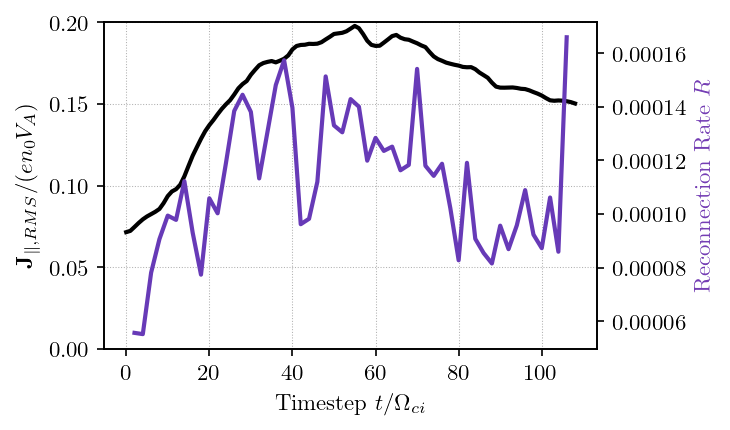

In [31]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")

def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 5.0)])
    max_r = np.mean(data)
    return max_r, len(data)

plt.figure(figsize=(4,3), dpi=150)

max_reconnection_rates = []
number_of_lines = []
for i, datapath in enumerate(all_files):
    max_r, n = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)
    number_of_lines.append(n)

fig, ax1 = plt.subplots(figsize=(5,3), dpi=150)

averaged_reconnection_rates = [1/2*max_reconnection_rates[i]*max_reconnection_rates[i+1] for i in np.arange(0, len(max_reconnection_rates)-1)[::2]]

ax2 = ax1.twinx()
ax2.plot(np.arange(0, len(max_reconnection_rates)-1)[::2], averaged_reconnection_rates,color=gcolor("violet"), linewidth=2.0)

# ax2.plot(number_of_points[:,0][:-5], number_of_points[:,1][:-5]/1e5, color="#743db4", linewidth=2)
ax1.plot(current_density[:,1], color="black", linewidth=2)
# ax2.plot(number_of_lines, color="#743db4", linewidth=2.0)
ax1.set_ylim(0,0.2)
ax1.set_xlabel(r"Timestep $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")
ax2.set_ylabel("Reconnection Rate $R$", color="#743db4")
ax2.grid(False)
plt.tight_layout()
# plt.savefig("/home/max/Nextcloud/Bachelor/Media/Plots/num_points_lines.pdf", dpi=300)
plt.show()